In [2]:
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import cv2

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.decomposition import PCA

import pickle

print("All libraries imported successfully.")

All libraries imported successfully.


In [6]:
BASE_DIR = os.path.join("forest_fire")

TRAIN_FIRE   = os.path.join(BASE_DIR, "Training and Validation", "fire")
TRAIN_NOFIRE = os.path.join(BASE_DIR, "Training and Validation", "nofire")
TEST_FIRE    = os.path.join(BASE_DIR, "Testing", "fire")
TEST_NOFIRE  = os.path.join(BASE_DIR, "Testing", "nofire")

IMG_SIZE   = (128, 128)   # resize target (W x H)
LABEL_MAP  = {"fire": 1, "nofire": 0}   # binary labels

for p in [TRAIN_FIRE, TRAIN_NOFIRE, TEST_FIRE, TEST_NOFIRE]:
    status = "Yes" if os.path.exists(p) else "Missing"
    print(f"{status}  {p}")

Yes  forest_fire\Training and Validation\fire
Yes  forest_fire\Training and Validation\nofire
Yes  forest_fire\Testing\fire
Yes  forest_fire\Testing\nofire


In [7]:
def preprocess_image(img_path, size=IMG_SIZE):
    """
    Load, resize, and normalize a single image.
    Returns: resized BGR image (uint8) or None on failure.
    """
    img = cv2.imread(img_path)
    if img is None:
        return None                          # skip corrupt / unreadable files
    img = cv2.resize(img, size)              # resize to fixed W×H
    return img


def extract_hog_features(gray_img):
    """
    Extract HOG (Histogram of Oriented Gradients) features using OpenCV.
    HOG encodes local gradient direction and magnitude — great for detecting
    the chaotic, irregular contours typical of fire/smoke regions.
    """
    hog = cv2.HOGDescriptor(
        _winSize  = (128, 128),   # must match resized image size
        _blockSize= (16, 16),
        _blockStride=(8, 8),
        _cellSize = (8, 8),
        _nbins    = 9             # 9 gradient orientation bins
    )
    features = hog.compute(gray_img)  # returns column vector
    return features.flatten()


def extract_hsv_histogram(bgr_img, bins=32):
    """
    Compute a normalized histogram in HSV color space.
    Fire pixels cluster in low-hue (red-orange), high-saturation, high-value.
    Separate histograms for H, S, V channels capture this signature well.
    """
    hsv = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2HSV)
    features = []
    # ranges: H [0,180], S [0,256], V [0,256]
    ranges = ([0, 180], [0, 256], [0, 256])
    for ch, (lo, hi) in enumerate(ranges):
        hist = cv2.calcHist([hsv], [ch], None, [bins], [lo, hi])
        hist = cv2.normalize(hist, hist).flatten()   # L2-normalize
        features.extend(hist)
    return np.array(features)


def extract_grayscale_stats(gray_img, grid=4):
    """
    Divide the grayscale image into a grid and compute local statistics
    (mean, std, skewness proxy) per cell. This captures texture variation —
    fire/smoke regions have high local variance.
    """
    h, w = gray_img.shape
    cell_h, cell_w = h // grid, w // grid
    stats = []
    for r in range(grid):
        for c in range(grid):
            cell = gray_img[
                r*cell_h:(r+1)*cell_h,
                c*cell_w:(c+1)*cell_w
            ].astype(np.float32)
            stats.append(cell.mean())
            stats.append(cell.std())
            # Simple skewness proxy: mean - median
            stats.append(cell.mean() - np.median(cell))
    return np.array(stats)


def extract_features(img_path):
    """
    Full pipeline for one image:
      1. Load & resize
      2. Convert to grayscale
      3. HOG features
      4. HSV histogram features
      5. Grayscale grid statistics
    Returns concatenated feature vector.
    """
    img = preprocess_image(img_path)
    if img is None:
        return None

    # Grayscale version (used by HOG and stats)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    hog_feat  = extract_hog_features(gray)          # ~3780 dims
    hsv_feat  = extract_hsv_histogram(img)          # 96  dims (3×32)
    stat_feat = extract_grayscale_stats(gray)        # 48  dims (4×4×3)

    return np.concatenate([hog_feat, hsv_feat, stat_feat])


print("Feature extraction functions defined.")
# Quick sanity-check on a dummy image
dummy = np.zeros((128, 128, 3), dtype=np.uint8)
gray_dummy = np.zeros((128, 128), dtype=np.uint8)
print(f"   HOG  feature size : {extract_hog_features(gray_dummy).shape[0]}")
print(f"   HSV  feature size : {extract_hsv_histogram(dummy).shape[0]}")
print(f"   Stat feature size : {extract_grayscale_stats(gray_dummy).shape[0]}")

Feature extraction functions defined.
   HOG  feature size : 8100
   HSV  feature size : 96
   Stat feature size : 48


In [ ]:
def load_folder(folder_path, label, verbose=True):
    """
    Iterate over all images in `folder_path`,
    extract features, and assign `label`.
    Returns lists: features, labels.
    """
    features, labels = [], []
    valid_ext = {".jpg", ".jpeg", ".png", ".bmp"}

    files = [
        f for f in os.listdir(folder_path)
        if os.path.splitext(f)[1].lower() in valid_ext
    ]

    for i, fname in enumerate(files):
        path = os.path.join(folder_path, fname)
        feat = extract_features(path)
        if feat is not None:
            features.append(feat)
            labels.append(label)
        if verbose and (i + 1) % 100 == 0:
            print(f"   Processed {i+1}/{len(files)} images...")

    print(f"Loaded {len(features)} images from: {os.path.basename(folder_path)}")
    return features, labels


# ─── Load Training + Validation data ────────────────────────────────
print("Loading Training & Validation — FIRE ...")
t0 = time.time()
X_tr_fire,   y_tr_fire   = load_folder(TRAIN_FIRE,   label=1)

print("Loading Training & Validation — NO FIRE ...")
X_tr_nofire, y_tr_nofire = load_folder(TRAIN_NOFIRE, label=0)

# ─── Load Testing data ───────────────────────────────────────────────
print("\nLoading Testing — FIRE ...")
X_te_fire,   y_te_fire   = load_folder(TEST_FIRE,    label=1)

print("Loading Testing — NO FIRE ...")
X_te_nofire, y_te_nofire = load_folder(TEST_NOFIRE,  label=0)

# ─── Combine into arrays ────────────────────────────────────────────
X_train_raw = np.array(X_tr_fire   + X_tr_nofire)
y_train_raw = np.array(y_tr_fire   + y_tr_nofire)
X_test_raw  = np.array(X_te_fire   + X_te_nofire)
y_test_raw  = np.array(y_te_fire   + y_te_nofire)

elapsed = time.time() - t0
print(f"\nFeature extraction complete in {elapsed:.1f}s")
print(f"   Train shape : {X_train_raw.shape} | Labels: {np.bincount(y_train_raw)}")
print(f"   Test  shape : {X_test_raw.shape}  | Labels: {np.bincount(y_test_raw)}")

Loading Training & Validation — FIRE ...
   Processed 100/928 images...
   Processed 200/928 images...
   Processed 300/928 images...
   Processed 400/928 images...
   Processed 500/928 images...
   Processed 600/928 images...
   Processed 700/928 images...
   Processed 800/928 images...
   Processed 900/928 images...
Loaded 928 images from: fire
Loading Training & Validation — NO FIRE ...
   Processed 100/904 images...
   Processed 200/904 images...
   Processed 300/904 images...
   Processed 400/904 images...
   Processed 500/904 images...
   Processed 600/904 images...
   Processed 700/904 images...
   Processed 800/904 images...
   Processed 900/904 images...
Loaded 904 images from: nofire

Loading Testing — FIRE ...
Loaded 22 images from: fire
Loading Testing — NO FIRE ...
Loaded 46 images from: nofire

Feature extraction complete in 11.6s
   Train shape : (1832, 8244) | Labels: [904 928]
   Test  shape : (68, 8244)  | Labels: [46 22]


In [9]:
# ─── Use the dataset's own split (preferred) ────────────────────────
X_train = X_train_raw.copy()
y_train = y_train_raw.copy()
X_test  = X_test_raw.copy()
y_test  = y_test_raw.copy()

print(f"Train samples : {X_train.shape[0]}")
print(f"Test  samples : {X_test.shape[0]}")
print(f"Feature dims  : {X_train.shape[1]}")

# ─── StandardScaler — zero mean, unit variance ──────────────────────
# Critical for SVM: it is sensitive to feature magnitude
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_scaled  = scaler.transform(X_test)         # apply same transform

print("\nStandardScaler applied.")
print(f"   Train mean (sample) : {X_train_scaled[0].mean():.4f}")
print(f"   Train std  (sample) : {X_train_scaled[0].std():.4f}")

Train samples : 1832
Test  samples : 68
Feature dims  : 8244

StandardScaler applied.
   Train mean (sample) : 0.0122
   Train std  (sample) : 0.9597


PCA: 8244 → 1139 components
   Explained variance: 95.0%


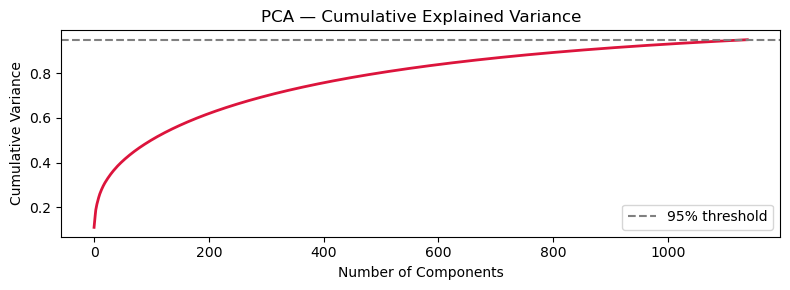

In [11]:
# Keep enough components to explain 95% of variance
pca = PCA(n_components=0.95, svd_solver='full', random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"PCA: {X_train_scaled.shape[1]} → {X_train_pca.shape[1]} components")
print(f"   Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Visualize scree plot
fig, ax = plt.subplots(figsize=(8, 3))
cumvar = np.cumsum(pca.explained_variance_ratio_)
ax.plot(cumvar, color='crimson', lw=2)
ax.axhline(0.95, ls='--', color='gray', label='95% threshold')
ax.set_xlabel("Number of Components"); ax.set_ylabel("Cumulative Variance")
ax.set_title("PCA — Cumulative Explained Variance")
ax.legend(); plt.tight_layout(); plt.show()

In [13]:
# ─── Train SVM with RBF kernel ───────────────────────────────────────
# C     : regularization — higher C → fits training data more tightly
# gamma : kernel bandwidth — 'scale' = 1/(n_features * X.var())
svm_rbf = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,     # needed for predict_proba (web UI)
    random_state=42
)

print("Training SVM (RBF) ...")
t0 = time.time()
svm_rbf.fit(X_train_pca, y_train)
print(f"Done in {time.time()-t0:.1f}s")

# ─── Quick baseline with Linear kernel for comparison ────────────────
svm_lin = SVC(kernel='linear', C=1, probability=True, random_state=42)
print("Training SVM (Linear) ...")
t0 = time.time()
svm_lin.fit(X_train_pca, y_train)
print(f"Done in {time.time()-t0:.1f}s")

Training SVM (RBF) ...
Done in 12.7s
Training SVM (Linear) ...
Done in 5.7s


In [14]:
# Manual grid — coarse search first, fine-tune around best
param_grid = {
    'C'     : [1, 10, 50, 100],
    'gamma' : ['scale', 'auto', 0.001, 0.01]
}

print("Running GridSearchCV (5-fold CV) — this may take a few minutes ...")
grid = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_pca, y_train)

print(f"\nBest params  : {grid.best_params_}")
print(f"   Best CV acc  : {grid.best_score_*100:.2f}%")

# Use best estimator going forward
best_svm = grid.best_estimator_

Running GridSearchCV (5-fold CV) — this may take a few minutes ...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best params  : {'C': 10, 'gamma': 'scale'}
   Best CV acc  : 89.58%


In [15]:
# ─── Predict on test set ────────────────────────────────────────────
y_pred_rbf  = svm_rbf.predict(X_test_pca)
y_pred_lin  = svm_lin.predict(X_test_pca)
y_pred_best = best_svm.predict(X_test_pca)

acc_rbf  = accuracy_score(y_test, y_pred_rbf)
acc_lin  = accuracy_score(y_test, y_pred_lin)
acc_best = accuracy_score(y_test, y_pred_best)

print("=" * 45)
print(f"  SVM RBF  (C=10)         : {acc_rbf*100:.2f}%")
print(f"  SVM Linear (C=1)        : {acc_lin*100:.2f}%")
print(f"  SVM Best (GridSearch)   : {acc_best*100:.2f}%")
print("=" * 45)

print("\nClassification Report (Best SVM):")
print(classification_report(y_test, y_pred_best,
      target_names=["No Fire", "Fire"]))

# 5-fold cross-validation on training set
cv_scores = cross_val_score(best_svm, X_train_pca, y_train, cv=5, scoring='accuracy')
print(f"\n5-Fold CV Accuracy: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")

  SVM RBF  (C=10)         : 91.18%
  SVM Linear (C=1)        : 94.12%
  SVM Best (GridSearch)   : 91.18%

Classification Report (Best SVM):
              precision    recall  f1-score   support

     No Fire       0.88      1.00      0.94        46
        Fire       1.00      0.73      0.84        22

    accuracy                           0.91        68
   macro avg       0.94      0.86      0.89        68
weighted avg       0.92      0.91      0.91        68


5-Fold CV Accuracy: 89.58% ± 2.48%


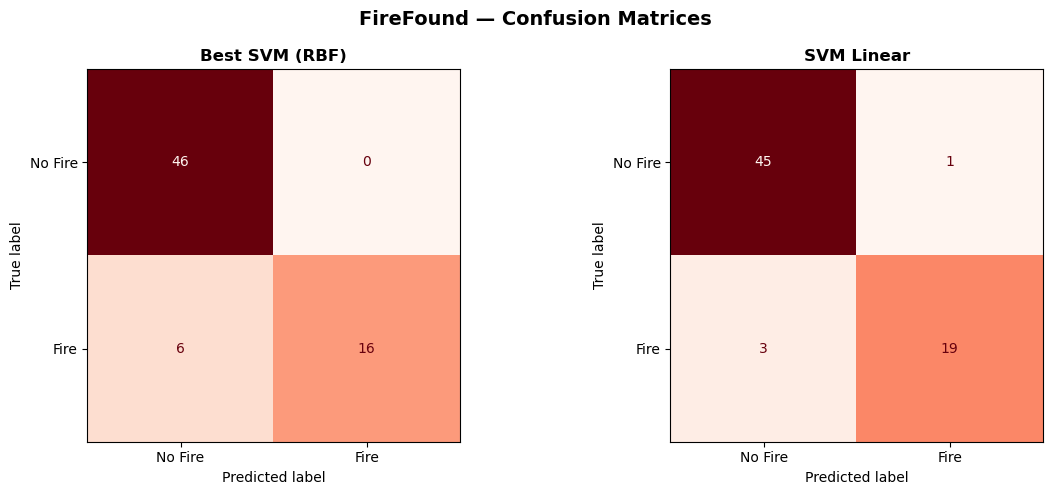

Confusion matrix saved.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("FireFound — Confusion Matrices", fontsize=14, fontweight='bold')

for ax, y_pred, title in zip(
    axes,
    [y_pred_best, y_pred_lin],
    ["Best SVM (RBF)", "SVM Linear"]
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Fire", "Fire"])
    disp.plot(ax=ax, colorbar=False, cmap="Reds")
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved.")

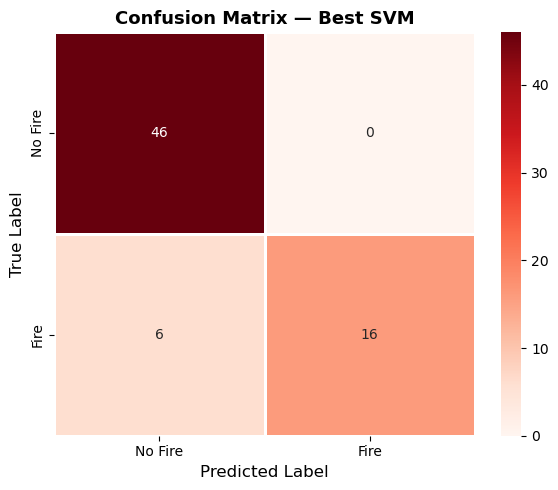

In [17]:
# Heatmap with seaborn — cleaner look
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Reds',
    xticklabels=['No Fire', 'Fire'],
    yticklabels=['No Fire', 'Fire'],
    linewidths=1, linecolor='white', ax=ax
)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("Confusion Matrix — Best SVM", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("confusion_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

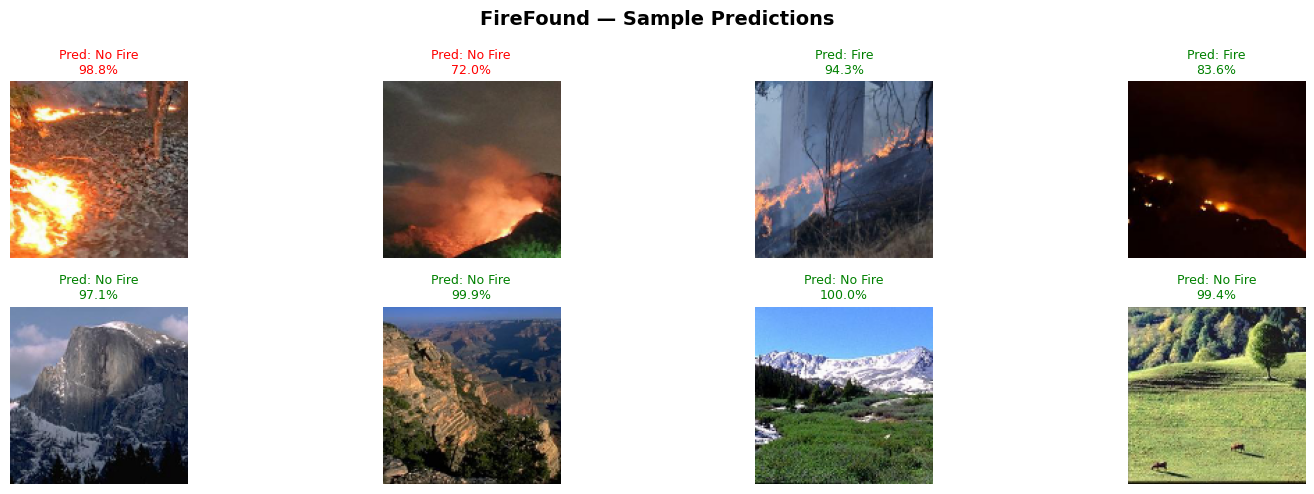

Sample prediction grid saved.


In [18]:
def predict_single(img_path, svm_model, scaler_obj, pca_obj):
    """Extract features from one image and return (prediction, probabilities)."""
    feat = extract_features(img_path)
    if feat is None:
        return None, None
    feat_scaled = scaler_obj.transform([feat])
    feat_pca    = pca_obj.transform(feat_scaled)
    pred  = svm_model.predict(feat_pca)[0]
    proba = svm_model.predict_proba(feat_pca)[0]
    return pred, proba


# ─── Display a grid of sample predictions ───────────────────────────
def show_predictions(fire_folder, nofire_folder, n=4):
    fig, axes = plt.subplots(2, n, figsize=(4*n, 5))
    fig.suptitle("FireFound — Sample Predictions", fontsize=14, fontweight='bold')

    for col, folder, true_label in zip(
        range(n),
        [fire_folder]*n,
        [1]*n
    ):
        files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        if col >= len(files): break
        path = os.path.join(folder, files[col])
        img  = cv2.cvtColor(cv2.resize(cv2.imread(path), IMG_SIZE), cv2.COLOR_BGR2RGB)
        pred, proba = predict_single(path, best_svm, scaler, pca)
        color = 'green' if pred == true_label else 'red'
        label = 'Fire' if pred == 1 else 'No Fire'
        axes[0][col].imshow(img)
        axes[0][col].set_title(f"Pred: {label}\n{max(proba)*100:.1f}%", color=color, fontsize=9)
        axes[0][col].axis('off')

    for col, folder, true_label in zip(
        range(n),
        [nofire_folder]*n,
        [0]*n
    ):
        files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        if col >= len(files): break
        path = os.path.join(folder, files[col])
        img  = cv2.cvtColor(cv2.resize(cv2.imread(path), IMG_SIZE), cv2.COLOR_BGR2RGB)
        pred, proba = predict_single(path, best_svm, scaler, pca)
        color = 'green' if pred == true_label else 'red'
        label = 'Fire' if pred == 1 else 'No Fire'
        axes[1][col].imshow(img)
        axes[1][col].set_title(f"Pred: {label}\n{max(proba)*100:.1f}%", color=color, fontsize=9)
        axes[1][col].axis('off')

    axes[0][0].set_ylabel("Fire Images",   fontsize=11, rotation=90)
    axes[1][0].set_ylabel("No-Fire Images", fontsize=11, rotation=90)
    plt.tight_layout()
    plt.savefig("sample_predictions.png", dpi=150, bbox_inches='tight')
    plt.show()


show_predictions(TEST_FIRE, TEST_NOFIRE, n=4)
print("Sample prediction grid saved.")

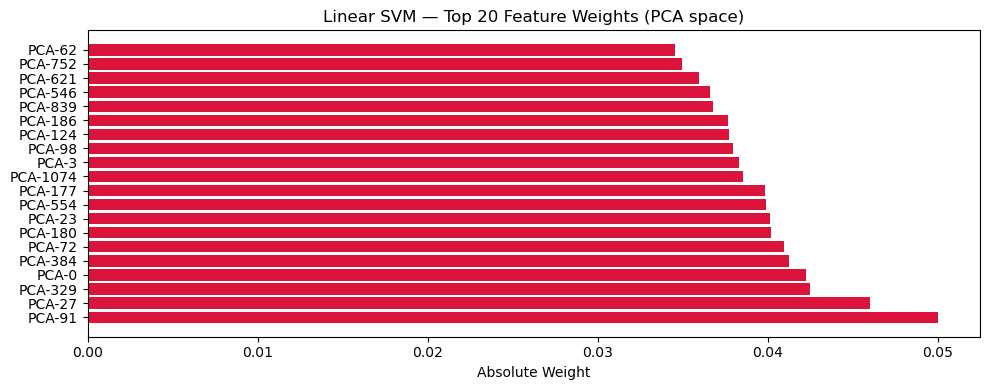

In [19]:
# For linear SVM we can visualise weight magnitudes
lin_weights = np.abs(svm_lin.coef_[0])
top_idx = np.argsort(lin_weights)[-20:][::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(range(20), lin_weights[top_idx], color='crimson')
ax.set_yticks(range(20))
ax.set_yticklabels([f"PCA-{i}" for i in top_idx])
ax.set_xlabel("Absolute Weight")
ax.set_title("Linear SVM — Top 20 Feature Weights (PCA space)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Save all components needed by the Flask web app
os.makedirs("../web/model", exist_ok=True)

with open("../web/model/svm_model.pkl",  "wb") as f: pickle.dump(best_svm, f)
with open("../web/model/scaler.pkl",     "wb") as f: pickle.dump(scaler,   f)
with open("../web/model/pca.pkl",        "wb") as f: pickle.dump(pca,      f)

print("Model artifacts saved to ../web/model/")
print(f"   svm_model.pkl | scaler.pkl | pca.pkl")
print(f"\nFinal Test Accuracy : {acc_best*100:.2f}%")

Model artifacts saved to ../web/model/
   svm_model.pkl | scaler.pkl | pca.pkl

Final Test Accuracy : 91.18%
